In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully!")
display(df.head())

Titanic dataset loaded successfully!


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone

In [4]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
print("Statistical Summary:")
display(df.describe())


Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("Survival Count:")
print(df["survived"].value_counts())

print("\nSurvival Percentage:")
print(df["survived"].value_counts(normalize=True) * 100)

Survival Count:
survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [7]:
print("Survival by Gender:")
display(pd.crosstab(df["sex"], df["survived"]))

print("\nSurvival Rate by Gender:")
display(df.groupby("sex")["survived"].mean() * 100)

Survival by Gender:


survived,0,1
sex,,
female,81,233
male,468,109



Survival Rate by Gender:


sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

In [8]:
print("Survival by Passenger Class:")
display(pd.crosstab(df["class"], df["survived"]))

print("\nSurvival Rate by Passenger Class:")
display(df.groupby("class", observed=True)["survived"].mean() * 100)

Survival by Passenger Class:


survived,0,1
class,,
First,80,136
Second,97,87
Third,372,119



Survival Rate by Passenger Class:


class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64

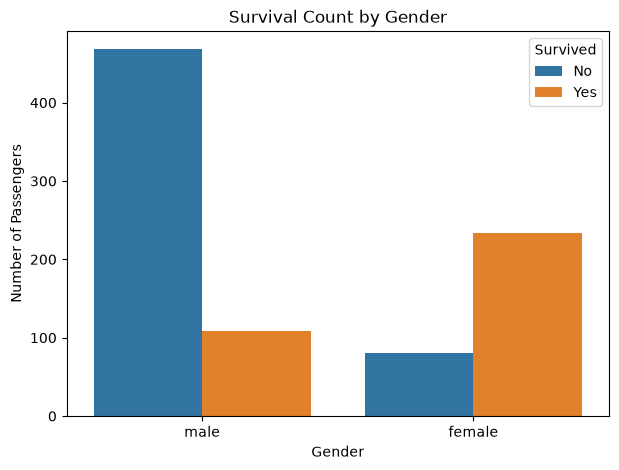

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

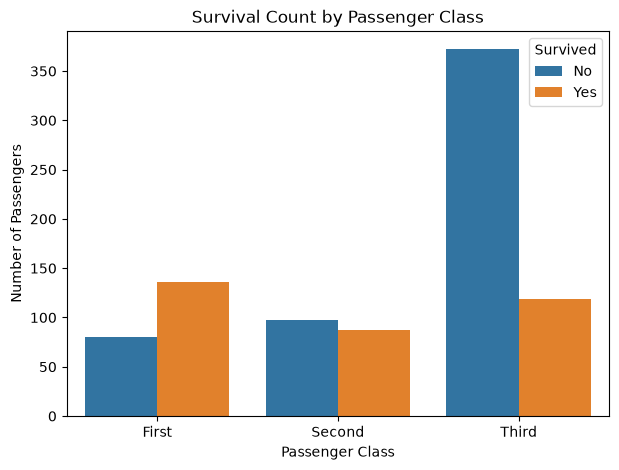

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="class", hue="survived")

plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

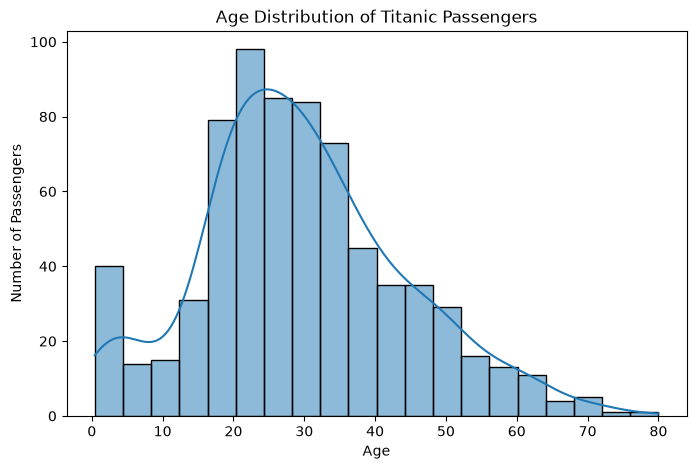

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=20, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

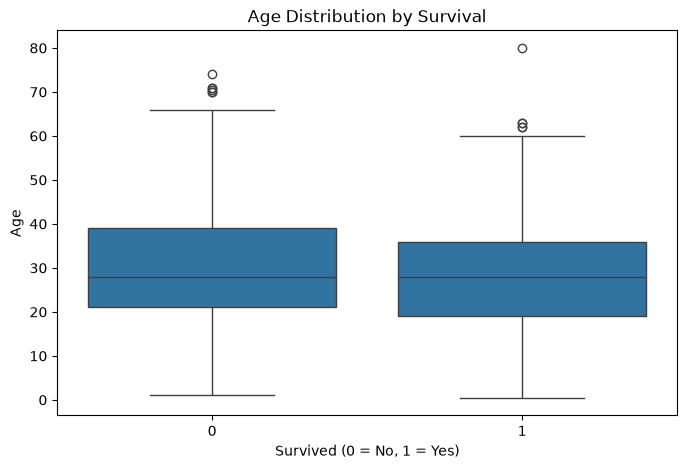

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="survived", y="age")

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

In [13]:
print("Survival by Embarkation Port:")
display(pd.crosstab(df["embarked"], df["survived"]))

print("\nSurvival Rate by Embarkation Port:")
display(df.groupby("embarked", observed=True)["survived"].mean() * 100)

Survival by Embarkation Port:


survived,0,1
embarked,,
C,75,93
Q,47,30
S,427,217



Survival Rate by Embarkation Port:


embarked
C    55.357143
Q    38.961039
S    33.695652
Name: survived, dtype: float64

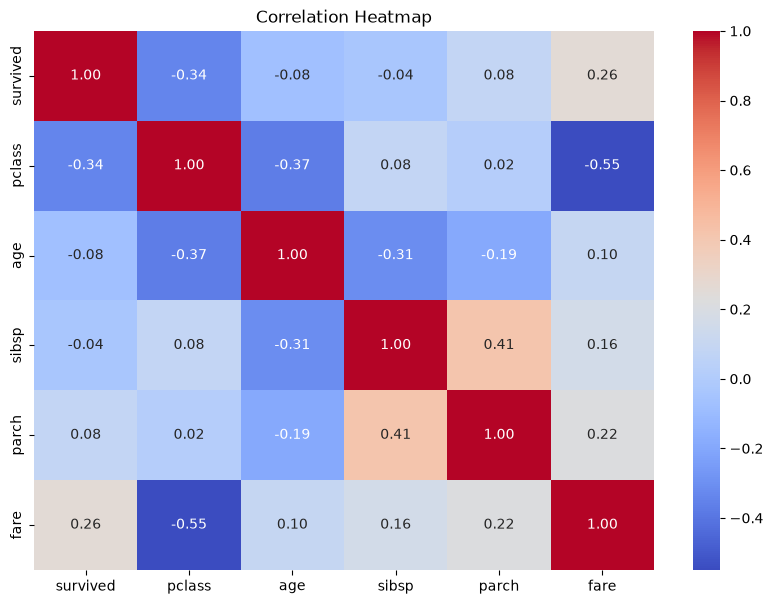

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

## Key Findings

1. The Titanic dataset contains information about passengers, including age, gender, passenger class, fare, and survival status.

2. The dataset contains missing values, particularly in columns such as age, cabin, and embarked.

3. Survival rates differed between male and female passengers.

4. Passenger class was associated with survival, with survival patterns differing across first, second, and third class.

5. Passenger ages showed a wide distribution, with both children and adults represented.

6. The analysis shows relationships between several numerical variables, including survival, age, fare, and passenger class.

7. Visualizations such as count plots, histograms, box plots, and a correlation heatmap helped identify patterns in the dataset.